# Event Data Exploration and Group Symmetry Checks
## This notebook extends '01_data_quality.ipynb' rather than repeating it. 
## It covers two areas not addressed there:
1. whether the data quality issues found in '01' are distributed evenly between the experimental groups
2. the duration of customer sessions, and what it implies for the time-based KPIs

## Importing Datasets

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

demo = pd.read_csv("../data/raw/df_final_demo.txt")
web1 = pd.read_csv("../data/raw/df_final_web_data_pt_1.txt")
web2 = pd.read_csv("../data/raw/df_final_web_data_pt_2.txt")
exp  = pd.read_csv("../data/raw/df_final_experiment_clients (1).txt")

web = pd.concat([web1, web2], ignore_index=True)
web["date_time"] = pd.to_datetime(web["date_time"])
web = web.sort_values(["client_id", "visit_id", "date_time"]).reset_index(drop=True)

print(web.shape)
print(web["date_time"].min(), "→", web["date_time"].max())

(755405, 5)
2017-03-15 00:03:03 → 2017-06-20 23:59:57


#### Events are sorted chronologically within each visit, since every analysis below depends on their order
#### The recorded activity spans 15 March to 20 June 2017, matching the A/B test period stated inthe project brief

------

### 1. Are data quality issues evenly spread across the groups?

#### Important to know if the data quality problems we found previously affect one group more than the other

Before comparing Test and Control, we need to know whether the data quality problems found earlier affect one group more than the other. If they do, differences in the results could come from the data rather than from the redesigned website.

#### **Inconsistency** : clients whose recorded tenure is longer than their recorded age -> not logically possible. 
#### The code below flags those records and attaches each client's experimental group, so the issue can be examined BY GROUP

In [2]:
demo["tenure_greater_than_age"] = demo["clnt_tenure_yr"] > demo["clnt_age"]
demo_with_group = demo.merge(exp, on="client_id", how="left")

demo["tenure_greater_than_age"].sum()

np.int64(574)

#### 574 clients (0.81% of the dataset) have a tenure longer than their age
#### Whether this matters for the experiment depends on how the affected clients are distributed between Test and Control

#### **First view — composition of the affected clients.**

In [3]:
(demo_with_group.loc[demo_with_group['tenure_greater_than_age'], "Variation"].value_counts(dropna=False, normalize=True) * 100).round(1)

Variation
NaN        42.3
Test       32.4
Control    25.3
Name: proportion, dtype: float64

#### This shows which group the affected clients come from +
#### it answers "where do these cases sit?", not "how much is each group affected?"

#### **Second view — rate within each group.**

why?
#### bc test is larger than control SO it contributes more affected clients even when both groups are affected at the same rate
#### by using the group size INSTEAD of the number of affected clients -> we get the SHARE OF EACH GROUP that is affected
#### which is truly useful to tell us whether the 2 groups are comparable

In [4]:
demo_with_group.groupby("Variation", dropna=False)["tenure_greater_than_age"].agg(    affected="sum", group_size="count", rate="mean")

,affected,group_size,rate
Variation,,,
Control,145,23532,0.006162
Test,186,26968,0.006897
NaN,243,20109,0.012084


#### Conclusion:
- The inconsistency affects ~0.62% of Control group' clients and ~0.69% of Test group' clients
- it means a difference less a difference of less than a tenth of a percentage point
- it means also that the two experimental groups are affected at ~ the same rate
#### we can affirm this data quality issues will not threaten the comparability of the 2 groups

#### Importante notes:
- the 'composition of affected clients' view suggested otherwise (32.4% Test against 25.3% Control)
- but that reflects Test group being the larger group rather than being more affected.
- also, we can observe that the unassigned clients are affected at roughly double the rate (1.21%)
#### - however they are excluded from the A/B comparison anyway, but this suggests they differ systematically from the assigned clients and should not be added back into the analysis later.

#### We can conclude that we should keep and flagged the data rather than remove it bc there is no sufficient proof that whether age or tenure is the incorrect value¶

------

### 2. Exploring the event data

#### Based on the "Identifier Hierarchy Investigation"
##### where 1645 visitor_id and 1012 visit_id are associated at more than 1 client_id

In [5]:
sessions = web.groupby(["client_id", "visit_id"]).agg(
    first_event=("date_time", "min"),
    last_event=("date_time", "max"),
    n_events=("process_step", "count"),
)
sessions["duration_min"] = (
    sessions["last_event"] - sessions["first_event"]
).dt.total_seconds() / 60

sessions["duration_min"].describe()

count    159112.000000
mean          5.216854
std           9.810366
min           0.000000
25%           0.700000
50%           2.816667
75%           5.950000
max         712.800000
Name: duration_min, dtype: float64

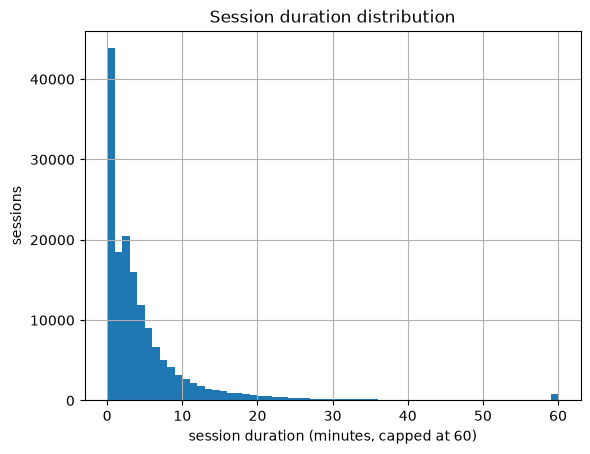

In [6]:
import matplotlib.pyplot as plt

sessions["duration_min"].clip(upper=60).hist(bins=60)
plt.xlabel("session duration (minutes, capped at 60)")
plt.ylabel("sessions")
plt.title("Session duration distribution")
plt.show()

#### The distribution is strongly right-skewed
#### the mean session lasts 5.2 minutes while the median is 2.8 minutes
#### and the longest session runs to 712.8 minutes (11.9 hours)
#### important: a minimum of zero minutes also appears -> needs explaining before any duration-based KPI is computed!

In [7]:
sessions["duration_min"].quantile([0.5, 0.75, 0.9, 0.95, 0.99, 0.999, 1]).round(1)

0.500      2.8
0.750      6.0
0.900     11.8
0.950     18.0
0.990     41.1
0.999    114.6
1.000    712.8
Name: duration_min, dtype: float64

#### the quantiles show where the tail begins. Most sessions are short
#### and the extreme values sit in a very small fraction of the data
#### which is why the mean is a poor summary here and the median should be preferred!!

In [8]:
for t in [30, 60, 120, 480]:
    n = (sessions["duration_min"] > t).sum()
    print(f"> {t:>3} min: {n:>6} sessions ({n / len(sessions) * 100:.2f}%)")

>  30 min:   3041 sessions (1.91%)
>  60 min:    733 sessions (0.46%)
> 120 min:     65 sessions (0.04%)
> 480 min:      4 sessions (0.00%)


#### Long sessions are rare but still real
#### We can not affirm that those are errors because we can theorize that: 
##### a session lasting several hours most likely reflects a customer who left the process open and returned later
##### rather than someone actively using the site for that entire period, logically it doesnt make sense
##### This distinction matters for Day 3, because Completion Time measured from first to last event would treat that idle time as engagement

In [9]:
single_event = (sessions["n_events"] == 1).sum()
print(f"single-event sessions: {single_event} ({single_event / len(sessions) * 100:.2f}%)")
print(f"zero-duration sessions: {(sessions['duration_min'] == 0).sum()}")

single-event sessions: 22591 (14.20%)
zero-duration sessions: 25140


#### Duration is calculated as 'last_event − first_event'
#### When a session contains a single event, the first and last event are the same one, so the difference is zero by construction

#### Two groups of sessions have no measurable duration:
#### - 22_591 sessions (14.2%) contain a single event, so there is no second timestamp to measure against
#### - 2549 sessions contain several events sharing an identical timestamp


#### Together -> 25_140 sessions have a duration of zero
#### ! These sessions did not last zero minutes -> there is simply nothing to measure!

#### **Decision**:
#### They are excluded from time-based KPIs, where a duration of zero would understate the average without reflecting real behaviour
#### BUT they are retained for completion and funnel metrics: a session containing only a 'start' is a genuine abandoned journey, and removing it from the denominator would inflate the completion rate by discarding exactly the journeys that ended earliest.

**Do long sessions occur equally in both groups?**

In [10]:
sessions_with_group = sessions.reset_index().merge(exp, on="client_id", how="left")
sessions_with_group["long_session"] = sessions_with_group["duration_min"] > 60

sessions_with_group.groupby("Variation", dropna=False)["long_session"].agg(
    long_sessions="sum", total="count", rate="mean"
)

,long_sessions,total,rate
Variation,,,
Control,73,32243,0.002264
Test,183,37204,0.004919
NaN,477,89665,0.005320


In [11]:
assigned = sessions_with_group[sessions_with_group["Variation"].notna()]
print(assigned["long_session"].sum(), "long sessions out of", len(assigned))

256 long sessions out of 69447


#### **Result.**:
#### Sessions longer than one hour occur at a rate of 0.23% in Control and 0.49% in Test
#### It means that Test sessions are roughly twice as likely to run long, although both rates are very small (256 long sessions -> 73+183 across 69_447 assigned sessions -> 32_243+37_204).

#### Unlike the demographic checks, this is not a comparability issue;
#### Age, tenure and balance are recorded before the experiment begins, so a difference between groups would indicate that randomisation failed (!) 
#### Session duration is measured *after* the customer has seen their assigned version of the site, which makes it an outcome rather than a baseline characteristic
#### A difference here is not evidence of imbalance —> it is a preliminary behavioural signal, and testing whether it is real belongs to Day 4.

#### **Implications for Day 3.**:
#### The longest session observed is 11.9 hours (~712min) and none spans more than one day, which suggests visit ids do not carry across days: a customer returning the next day appears as a new visit. 
#### Two decisions can follow from this: 

#### 1. whether a gap threshold is applied when measuring Effective Time, so idle periods are not count as time spent progressing
#### 2. whether sessions with no measurable duration are excluded from time-based metrics